<a href="https://colab.research.google.com/github/Junaidirah/predictive_pm25/blob/master/notebook/explorasi_data/eda_tult.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [6]:
data_path_2024 = "/content/tult_valid-2024.csv"
data_path_2025 = "/content/tult_valid_2025.csv"

In [7]:
df_2024 = pd.read_csv(data_path_2024)
df_2025 = pd.read_csv(data_path_2025)

In [13]:
df_2024.tail()

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
188336,290041,2024-12-30 23:52:00,22.1,84.0,21.74,86.0,556.76,0.0,7.03,NaN,NaN,NaN,NaN,NaN
188337,290042,2024-12-30 23:54:00,22.0,85.0,21.69,86.0,556.77,0.0,6.84,NaN,NaN,NaN,NaN,NaN
188338,290043,2024-12-30 23:56:00,22.0,85.0,21.69,86.0,559.76,0.0,5.35,NaN,NaN,NaN,NaN,NaN
188339,290044,2024-12-30 23:58:00,22.0,85.0,21.68,86.0,560.69,0.0,5.98,NaN,NaN,NaN,NaN,NaN
188340,290045,2024-12-31 00:00:00,21.9,85.0,21.65,86.0,561.75,0.0,6.99,NaN,NaN,NaN,NaN,NaN


In [14]:
df = pd.concat([df_2024, df_2025])
df.head(10)

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
0,95583,2024-02-01 00:00:00,23.2,96.0,NaN,NaN,742.00415,13.501251,NaN,NaN,NaN,NaN,NaN,NaN
1,95584,2024-02-01 00:02:00,23.1,95.8,NaN,NaN,738.07513,12.292184,NaN,NaN,NaN,NaN,NaN,NaN
2,95585,2024-02-01 00:04:00,23.1,95.9,NaN,95.63744,738.97504,12.493695,NaN,NaN,NaN,NaN,NaN,NaN
3,95586,2024-02-01 00:06:00,23.2,95.8,NaN,NaN,739.06677,12.292184,NaN,NaN,NaN,NaN,NaN,NaN
4,95587,2024-02-01 00:08:00,23.2,95.6,NaN,NaN,740.96039,12.695206,NaN,NaN,NaN,NaN,NaN,NaN
5,95588,2024-02-01 00:10:00,23.2,95.4,NaN,NaN,740.03119,12.896717,NaN,NaN,NaN,NaN,NaN,NaN
6,95589,2024-02-01 00:12:00,23.3,95.8,NaN,NaN,735.95624,11.486139,NaN,NaN,NaN,NaN,NaN,NaN
7,95590,2024-02-01 00:14:00,23.3,95.4,NaN,95.60998,732.03192,11.083117,NaN,NaN,NaN,NaN,NaN,NaN
8,95591,2024-02-01 00:16:00,23.3,95.3,NaN,NaN,724.09625,11.687650,NaN,NaN,NaN,NaN,NaN,NaN
9,95592,2024-02-01 00:18:00,23.3,95.1,NaN,95.54131,720.03290,11.687650,NaN,NaN,NaN,NaN,NaN,NaN


### cleaning

In [15]:
df.describe()

,id,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
count,403342.000000,402629.000000,403147.000000,331944.000000,344867.000000,372587.000000,398053.000000,240784.000000,894.000000,30979.000000,0.0,0.0,0.0
mean,301359.748276,26.628209,70.780955,24.285757,79.307344,614.409464,38.477158,2.505101,0.248322,586.017040,NaN,NaN,NaN
std,119253.814337,4.194646,17.220116,6.593833,17.165848,175.078604,24.397699,2.731018,7.424791,448.498046,NaN,NaN,NaN
min,95583.000000,-7.600000,0.000000,-8.810000,0.000000,398.290000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,196447.250000,24.000000,61.000000,21.550000,68.000000,528.870000,22.000000,0.160000,0.000000,0.000000,NaN,NaN,NaN
50%,304077.500000,26.380000,71.000000,23.523310,84.000000,609.510250,36.000000,2.070000,0.000000,925.697300,NaN,NaN,NaN
75%,404912.750000,29.030000,84.000000,28.490000,92.733650,676.190000,50.000000,4.040000,0.000000,927.869200,NaN,NaN,NaN
max,505748.000000,80.000000,100.000000,80.000000,100.000000,4989.965820,303.000000,27.700000,222.000000,1233.431700,NaN,NaN,NaN


In [16]:
df.isnull().sum()

,0
id,0
created_at,0
temperature,713
humidity,195
sht31_temp,71398
sht31_hum,58475
co2,30755
pm25,5289
ws,162558
wd,402448


In [17]:
df['created_at'] = pd.to_datetime(df['created_at'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403342 entries, 0 to 215000
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           403342 non-null  int64         
 1   created_at   403342 non-null  datetime64[ns]
 2   temperature  402629 non-null  float64       
 3   humidity     403147 non-null  float64       
 4   sht31_temp   331944 non-null  float64       
 5   sht31_hum    344867 non-null  float64       
 6   co2          372587 non-null  float64       
 7   pm25         398053 non-null  float64       
 8   ws           240784 non-null  float64       
 9   wd           894 non-null     float64       
 10  pressure     30979 non-null   float64       
 11  solar        0 non-null       float64       
 12  solar_cast   0 non-null       float64       
 13  rainfall     0 non-null       float64       
dtypes: datetime64[ns](1), float64(12), int64(1)
memory usage: 46.2 MB


In [18]:
df['year'] = df['created_at'].dt.year
df.head()

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall,year
0,95583,2024-02-01 00:00:00,23.2,96.0,NaN,NaN,742.00415,13.501251,NaN,NaN,NaN,NaN,NaN,NaN,2024
1,95584,2024-02-01 00:02:00,23.1,95.8,NaN,NaN,738.07513,12.292184,NaN,NaN,NaN,NaN,NaN,NaN,2024
2,95585,2024-02-01 00:04:00,23.1,95.9,NaN,95.63744,738.97504,12.493695,NaN,NaN,NaN,NaN,NaN,NaN,2024
3,95586,2024-02-01 00:06:00,23.2,95.8,NaN,NaN,739.06677,12.292184,NaN,NaN,NaN,NaN,NaN,NaN,2024
4,95587,2024-02-01 00:08:00,23.2,95.6,NaN,NaN,740.96039,12.695206,NaN,NaN,NaN,NaN,NaN,NaN,2024


In [19]:
nan_counts_by_year = df.groupby('year')[df.columns.drop('year')].apply(lambda x: x.isnull().sum())
print(nan_counts_by_year)

      id  created_at  temperature  humidity  sht31_temp  sht31_hum    co2  \
year                                                                        
2024   0           0          578       110       71289      58372  12204   
2025   0           0          135        85         109        103  18551   

      pm25      ws      wd  pressure   solar  solar_cast  rainfall  
year                                                                
2024  5242  162481  188341    158234  188341      188341    188341  
2025    47      77  214107    214129  215001      215001    215001  


In [20]:
df = df.drop(columns=['co2', 'ws', 'wd', 'pressure', 'solar', 'solar_cast', 'rainfall'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403342 entries, 0 to 215000
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           403342 non-null  int64         
 1   created_at   403342 non-null  datetime64[ns]
 2   temperature  402629 non-null  float64       
 3   humidity     403147 non-null  float64       
 4   sht31_temp   331944 non-null  float64       
 5   sht31_hum    344867 non-null  float64       
 6   pm25         398053 non-null  float64       
 7   year         403342 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(1)
memory usage: 26.2 MB


In [21]:
df.set_index('created_at', inplace=True, drop=True)
df.head()

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year
created_at,,,,,,,
2024-02-01 00:00:00,95583,23.2,96.0,NaN,NaN,13.501251,2024
2024-02-01 00:02:00,95584,23.1,95.8,NaN,NaN,12.292184,2024
2024-02-01 00:04:00,95585,23.1,95.9,NaN,95.63744,12.493695,2024
2024-02-01 00:06:00,95586,23.2,95.8,NaN,NaN,12.292184,2024
2024-02-01 00:08:00,95587,23.2,95.6,NaN,NaN,12.695206,2024


In [22]:
hourly_counts = df.resample('h').count()
hourly_means = df.resample('h').mean()

# Apply the condition: set mean to NaN if count < 23
for col in hourly_means.columns:
    hourly_means.loc[hourly_counts[col] < 23, col] = np.nan

# Round numerical columns to 2 decimal places (excluding 'year' which should be integer)
for col in hourly_means.columns:
    if pd.api.types.is_numeric_dtype(hourly_means[col]) and col != 'year':
        hourly_means[col] = hourly_means[col].round(2)

# Convert 'year' to integer, handling potential NaN values
if 'year' in hourly_means.columns:
    hourly_means['year'] = hourly_means['year'].apply(lambda x: int(x) if pd.notna(x) else x)

# Replace the 'id' column with a sequential series starting from 1
hourly_means['id'] = range(1, len(hourly_means) + 1)

# Reorder columns to ensure 'id' is the first column
current_cols = hourly_means.columns.tolist()
if 'id' in current_cols:
    current_cols.remove('id')
hourly_means = hourly_means[['id'] + current_cols]

# Display the first and last 5 rows
hourly_means.head(10)

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year
created_at,,,,,,,
2024-01-01 00:00:00,1,22.40,96.22,NaN,NaN,31.17,2024.0
2024-01-01 01:00:00,2,22.48,94.71,NaN,NaN,19.70,2024.0
2024-01-01 02:00:00,3,21.94,96.98,NaN,NaN,32.68,2024.0
2024-01-01 03:00:00,4,21.75,96.47,NaN,NaN,26.13,2024.0
2024-01-01 04:00:00,5,21.56,97.31,NaN,NaN,25.10,2024.0
2024-01-01 05:00:00,6,21.69,96.56,NaN,NaN,23.63,2024.0
2024-01-01 06:00:00,7,22.63,96.11,NaN,NaN,29.52,2024.0
2024-01-01 07:00:00,8,24.12,91.44,NaN,NaN,34.93,2024.0
2024-01-01 08:00:00,9,27.14,79.97,NaN,NaN,27.43,2024.0


In [23]:
hourly_means['month'] = hourly_means.index.month

df_2024_hourly = hourly_means[hourly_means['year'] == 2024.0]
df_2025_hourly = hourly_means[hourly_means['year'] == 2025.0]

df_combined_hourly = pd.concat([df_2024_hourly, df_2025_hourly])

df_combined_hourly.head()

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,22.40,96.22,NaN,NaN,31.17,2024.0,1
2024-01-01 01:00:00,2,22.48,94.71,NaN,NaN,19.70,2024.0,1
2024-01-01 02:00:00,3,21.94,96.98,NaN,NaN,32.68,2024.0,1
2024-01-01 03:00:00,4,21.75,96.47,NaN,NaN,26.13,2024.0,1
2024-01-01 04:00:00,5,21.56,97.31,NaN,NaN,25.10,2024.0,1


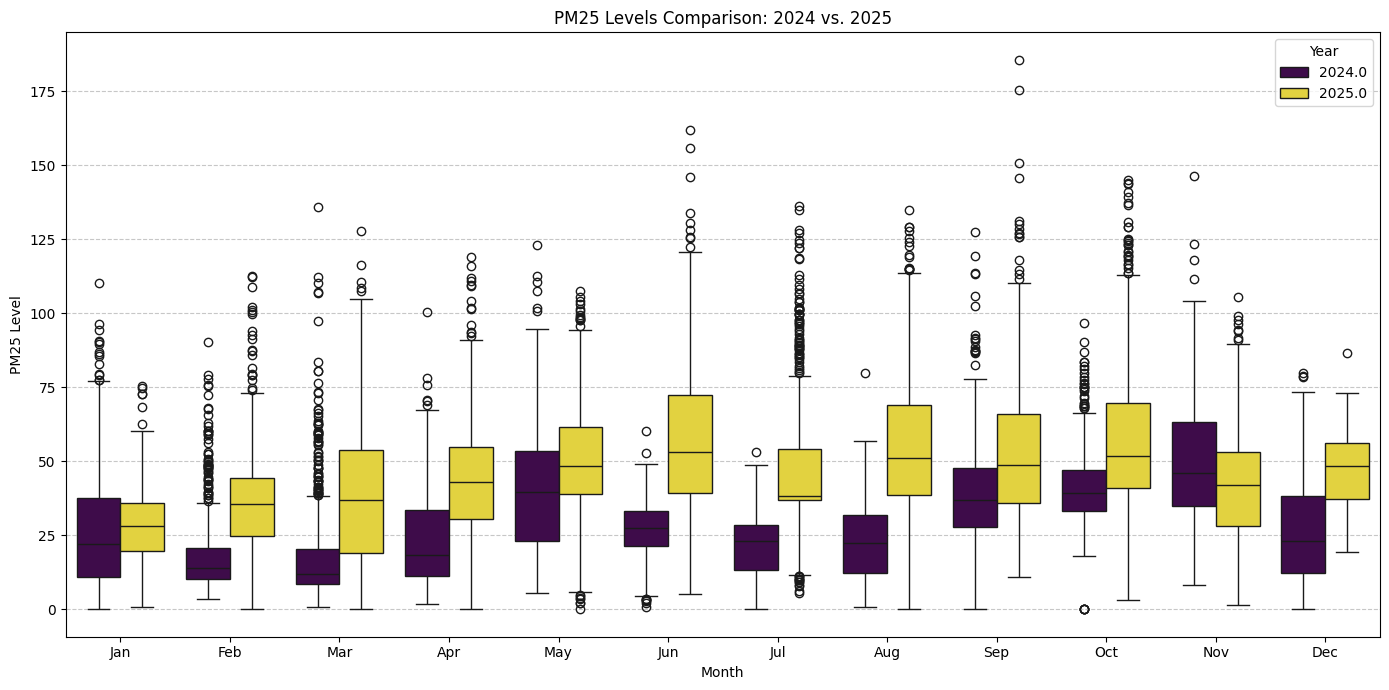

In [24]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='pm25', hue='year', data=df_combined_hourly, palette='viridis')
plt.title('PM25 Levels Comparison: 2024 vs. 2025')
plt.xlabel('Month')
plt.ylabel('PM25 Level')
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

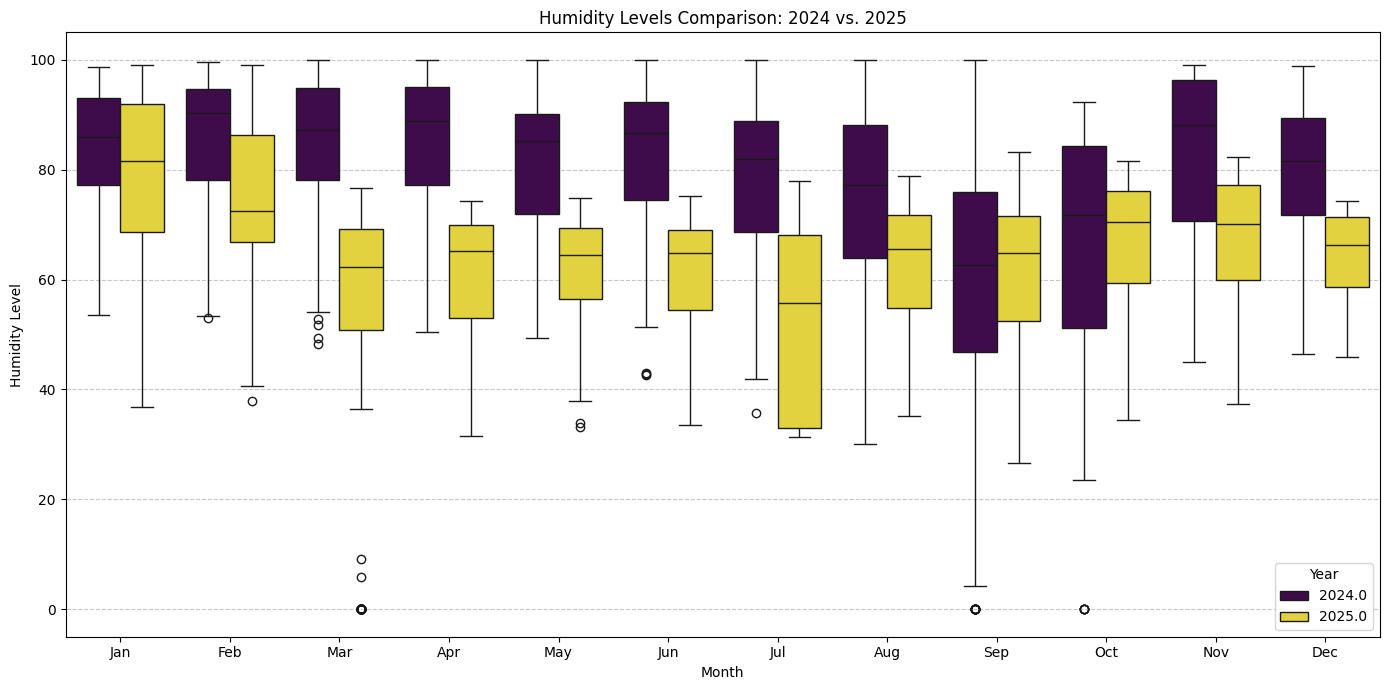

In [25]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='humidity', hue='year', data=df_combined_hourly, palette='viridis')
plt.title('Humidity Levels Comparison: 2024 vs. 2025')
plt.xlabel('Month')
plt.ylabel('Humidity Level')
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Cleaning Outlier

In [26]:
import numpy as np

# Define target columns
target_columns = ['pm25', 'temperature', 'humidity']

# 1. Function to remove outliers using IQR
def remove_outliers(group):
    for col in target_columns:
        if col in group.columns and not group[col].isnull().all():
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Set outliers to NaN
            group.loc[(group[col] < lower_bound) | (group[col] > upper_bound), col] = np.nan
    return group

# 2. Apply cleaning multiple times (5 passes) to reach absolute stability
for i in range(6):
    df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)

print("Data cleaning (5 passes) completed.")

# 3. Final Verification for visual consistency
sample_year, sample_month = 2024.0, 1
cleaned_sample_group = df_combined_hourly[(df_combined_hourly['year'] == sample_year) & (df_combined_hourly['month'] == sample_month)]

print(f"\n--- Final Outlier Check (Year: {int(sample_year)}, Month: {sample_month}) ---")
for col in target_columns:
    if not cleaned_sample_group[col].isnull().all():
        Q1, Q3 = cleaned_sample_group[col].quantile(0.25), cleaned_sample_group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = cleaned_sample_group[(cleaned_sample_group[col] < lower) | (cleaned_sample_group[col] > upper)]
        print(f"  {col}: {len(outliers)} outliers remaining in sample group.")

/tmp/ipykernel_22327/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_22327/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_22327/132

Data cleaning (5 passes) completed.

--- Final Outlier Check (Year: 2024, Month: 1) ---
  pm25: 0 outliers remaining in sample group.
  temperature: 0 outliers remaining in sample group.
  humidity: 0 outliers remaining in sample group.


/tmp/ipykernel_22327/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_22327/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)


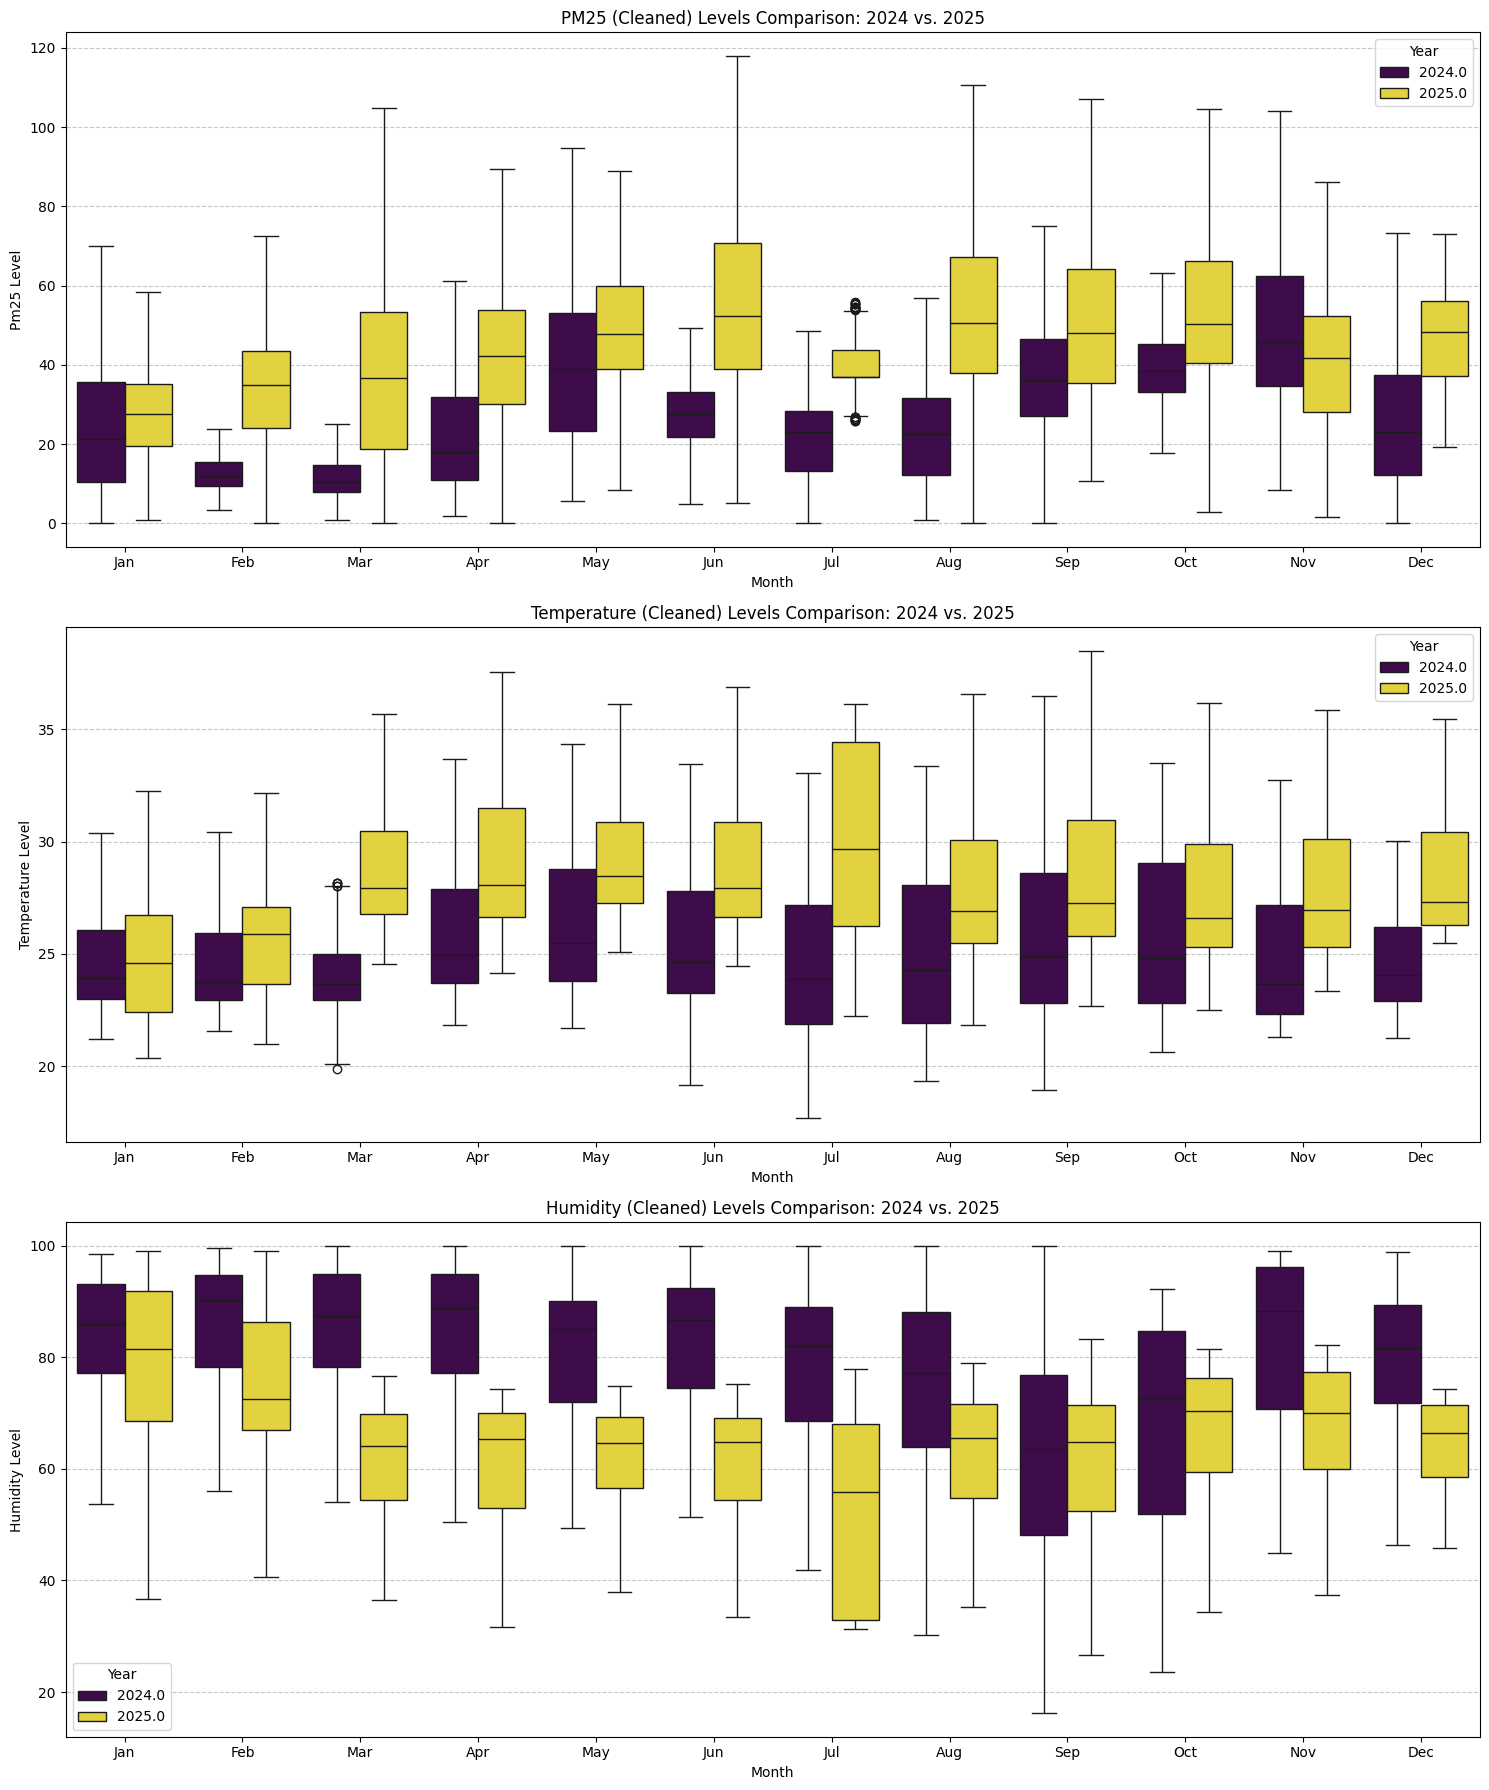

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
target_cols = ['pm25', 'temperature', 'humidity']
col_titles = ['PM25 (Cleaned)', 'Temperature (Cleaned)', 'Humidity (Cleaned)']

for i, col in enumerate(target_cols):
    sns.boxplot(ax=axes[i], x='month', y=col, hue='year', data=df_combined_hourly, palette='viridis')
    axes[i].set_title(f'{col_titles[i]} Levels Comparison: 2024 vs. 2025')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(f'{col.capitalize()} Level')
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels([calendar.month_abbr[m+1] for m in range(12)])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend(title='Year')

plt.tight_layout()
plt.show()

In [28]:
print("Head of cleaned df_combined_hourly:")
display(df_combined_hourly.head())

print("\nTail of cleaned df_combined_hourly:")
display(df_combined_hourly.tail())

Head of cleaned df_combined_hourly:


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,22.40,96.22,NaN,NaN,31.17,2024.0,1
2024-01-01 01:00:00,2,22.48,94.71,NaN,NaN,19.70,2024.0,1
2024-01-01 02:00:00,3,21.94,96.98,NaN,NaN,32.68,2024.0,1
2024-01-01 03:00:00,4,21.75,96.47,NaN,NaN,26.13,2024.0,1
2024-01-01 04:00:00,5,21.56,97.31,NaN,NaN,25.10,2024.0,1



Tail of cleaned df_combined_hourly:


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2025-12-11 17:00:00,17058,26.64,60.77,0.0,0.0,33.50,2025.0,12
2025-12-11 18:00:00,17059,25.96,58.40,0.0,0.0,34.73,2025.0,12
2025-12-11 19:00:00,17060,25.93,59.20,0.0,0.0,38.00,2025.0,12
2025-12-11 20:00:00,17061,25.79,59.60,0.0,0.0,49.87,2025.0,12
2025-12-11 21:00:00,17062,25.75,59.90,0.0,0.0,48.63,2025.0,12


In [29]:
target_columns = ['pm25', 'temperature', 'humidity']
null_counts_after_cleaning = df_combined_hourly[target_columns].isnull().sum()

print("Final Null Counts in Target Columns (After 5-pass IQR Cleaning):")
print(null_counts_after_cleaning)

Final Null Counts in Target Columns (After 5-pass IQR Cleaning):
pm25           919
temperature    281
humidity       113
dtype: int64


In [31]:
# Membuat dataset final untuk pelatihan model
data_training_tult = df_combined_hourly.copy()

# Menampilkan informasi dataset baru
print("Dataset 'data_training_tult' berhasil dibuat.")
print(f"Jumlah baris: {data_training_tult.shape[0]}")
print(f"Jumlah kolom: {data_training_tult.shape[1]}")
display(data_training_tult.head(5))

Dataset 'data_training_tult' berhasil dibuat.
Jumlah baris: 13365
Jumlah kolom: 8


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,22.40,96.22,NaN,NaN,31.17,2024.0,1
2024-01-01 01:00:00,2,22.48,94.71,NaN,NaN,19.70,2024.0,1
2024-01-01 02:00:00,3,21.94,96.98,NaN,NaN,32.68,2024.0,1
2024-01-01 03:00:00,4,21.75,96.47,NaN,NaN,26.13,2024.0,1
2024-01-01 04:00:00,5,21.56,97.31,NaN,NaN,25.10,2024.0,1


In [32]:
# Menyimpan dataset final ke file CSV
file_name = "data_training_tult.csv"
data_training_tult.to_csv(file_name, index=True)

print(f"Dataset berhasil disimpan dengan nama: {file_name}")

Dataset berhasil disimpan dengan nama: data_training_tult.csv
